# Quantification of Mitochondria in 2D Fluorescent Stacks
- *Isobel Taylor-Hearn, 2023*
- Requires a fluorescent image stack containing (at least) a nuclear channel and mitochondria channel

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
from skimage import util,  restoration

import skimage
from skimage.feature import peak_local_max
from skimage import util,  restoration
from skimage.filters import threshold_otsu, threshold_isodata, threshold_triangle, gaussian
from skimage.segmentation import clear_border, expand_labels, watershed
from skimage.measure import label, regionprops_table
from skimage.morphology import remove_small_holes, remove_small_objects, closing,  erosion, disk, dilation, h_maxima
from scipy.ndimage import distance_transform_edt
from scipy import ndimage as ndi
from tifffile import imread, imwrite
from skimage.filters import try_all_threshold

import warnings
warnings.filterwarnings("ignore")
import pathlib
from pathlib import Path
import contextlib
import joblib
from tqdm import tqdm
from joblib import Parallel, delayed

In [33]:
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """
    Enables parallel jobs to run and display of a tqdm progress bar.

    Parameters:
    -----------
    tqdm_object : tqdm
        The tqdm progress bar instance to be updated.

    """
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

In [34]:
def convert(img, target_type_min, target_type_max, target_type):
    """
    Converts an image to a specified data type while scaling its intensity values.

    This function rescales the intensity values of an image from its original range 
    to a new target range specified by `target_type_min` and `target_type_max`, and 
    then converts it to the desired data type.

    This step is required as deconvolved images are not always scaled 0->255! 

    Parameters:
    -----------
    img : numpy.ndarray
        The input image array to be converted.
    target_type_min : int or float
        The minimum value of the target intensity range.
    target_type_max : int or float
        The maximum value of the target intensity range.
    target_type : numpy.dtype
        The desired data type of the output image (e.g., np.uint8, np.float32).

    Returns:
    --------
    new_img : numpy.ndarray
        The rescaled image with values mapped to the new intensity range and converted 
        to the specified data type.

    Notes:
    ------
    - This function performs a linear transformation to scale pixel values.
    - It ensures that the output values are properly mapped between `target_type_min` and 
      `target_type_max`.
    """
    imin = img.min()
    imax = img.max()
    a = (target_type_max - target_type_min) / (imax - imin)
    b = target_type_max - a * imax
    new_img = (a * img + b).astype(target_type)
    return new_img

In [35]:
def add_image_details(df, filename):
    """
    Adds experimental details extracted from the filename to a dataframe.

    This function parses the filename to infer experimental details such as 
    well number, imaging day, mechanical stiffness condition, and treatment type.
    The extracted details are appended as new columns to the dataframe.

    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe to which image metadata will be added.
    filename : str
        The filename of the image, used to extract experimental details.

    Returns:
    --------
    df : pandas.DataFrame
        The updated dataframe with the following added columns:
        - 'filename': The original filename.
        - 'treatment': 250PFOA, 125PFOA, 175PFOA, 10PFOA, 1PFOA, 80PFOA, 40PFOA, ethanol, media, triton, or unknown

    """

    df["filename"] = filename.lower()
    filename = filename.lower()
    if "250pfoa" in filename:
        df["treatment"] = "250PFOA" 
    elif "500pfos" in filename:
        df["treatment"] = "500PFOS"
    elif "350pfos" in filename:
        df["treatment"] = "300PFOS"
    elif "175pfoa" in filename:
        df["treatment"] = "175PFOA"
    elif "125pfoa" in filename:
        df["treatment"] = "125PFOA"  
    elif "80pfoa" in filename:
        df["treatment"] = "80PFOA"
    elif "40pfoa" in filename:
        df["treatment"] = "40PFOA"
    elif "10pfoa" in filename:
        df["treatment"] = "10PFOA"
    elif "1pfoa" in filename:
        df["treatment"] = "1PFOA"
    elif "250pfos" in filename:
        df["treatment"] = "250PFOS" 
    elif "125pfos" in filename:
        df["treatment"] = "125PFOS"  
    elif "175pfos" in filename:
        df["treatment"] = "175PFOS"
    elif "10pfos" in filename:
        df["treatment"] = "10PFOS"
    elif "1pfos" in filename:
        df["treatment"] = "1PFOS"
    elif "80pfos" in filename:
        df["treatment"] = "80PFOS"
    elif "40pfos" in filename:
        df["treatment"] = "40PFOS"
    elif "2etoh" in filename:
        df["treatment"] = "2x_ethanol"
    elif "etoh" in filename:
        df["treatment"] = "ethanol"
    elif "media" in filename:
        df["treatment"] = "media"
    elif "triton" in filename:
        df["treatment"] = "triton"
    else:
        df["treatment"] = "unknown"  
    df["well"] = filename.split("-")[1].split("_")[0]


    return df

In [36]:
def segment_nuclei_and_quantify_protein(dapi_paths, eth_paths, i, to_plot=True, pos_threshold=0.3, output_directory=Path(r"Z:\Chiara\Opera\20260424_HUVEC_EthD\Processing\Python_Output")):
    """
    Segment nuclei from paired DAPI/EthD images, measure the total (summed) EthD
    intensity within each nucleus, and classify each nucleus as EthD positive/negative
    based on the proportion of its area occupied by EthD-positive labels.

    Parameters
    ----------
    pos_threshold : float, optional (default=0.3)
        A nucleus is EthD positive if the fraction of its area occupied by EthD-positive
        labels is greater than or equal to this value.

    Returns
    -------
    all_props : pandas.DataFrame
        Columns include:
        - filename
        - treatment
        - well
        - nucleus_label
        - nucleus_area_px
        - eth_intensity_in_nucleus (summed EthD pixel intensity within the nucleus)
        - eth_area_in_nucleus_px (area covered by EthD-positive labels within the nucleus)
        - eth_fraction_in_nucleus (eth_area_in_nucleus_px / nucleus_area_px)
        - eth_status ("positive" or "negative")
    """
    filename = os.path.basename(dapi_paths[i])
    dapi_image = convert(imread(dapi_paths[i]), 0, 255, np.uint8)
    eth_image = convert(imread(eth_paths[i]), 0, 255, np.uint8)

    # SEGMENTATION #############################################################
    dapi_mask = dapi_image > threshold_triangle(dapi_image)
    dapi_mask = remove_small_holes(dapi_mask, area_threshold=150)
    dapi_mask = remove_small_objects(dapi_mask, min_size=80)

    dist_s = gaussian( ndi.distance_transform_edt(dapi_mask), sigma=1.0)
    coords = peak_local_max(dist_s, labels=dapi_mask, min_distance=20)

    markers = np.zeros(dapi_mask.shape, dtype=np.int32)
    markers[tuple(coords.T)] = np.arange(1, len(coords) + 1)
    dapi_labels_ws = watershed(-dist_s, markers, mask=dapi_mask, watershed_line=True)

    # Segment EthD.
    eth_mask = eth_image > threshold_triangle(eth_image)
    eth_labels = label(eth_mask)
    fig, ax = try_all_threshold(eth_image)
    output_directory.mkdir(parents=True, exist_ok=True)

    plt.savefig(output_directory / f"{filename}_try_all_eth_thresh.png", bbox_inches="tight")
    # Identify very large objects (bubbles/artifacts/debris....) in each channel.
    # Instead of simply deleting these large objects, a large artefact in one channel
    # is used to black out / exclude any labels in the *other* channel that overlap it.
    # This prevents a large EthD blob from smearing signal across the nuclei beneath it
    # and causing genuine cells to be miscounted as EthD-negative when they should
    # instead be discarded from the counts / analysis entirely.
    dapi_props = regionprops_table(dapi_labels_ws, properties=("label", "area"))
    dapi_large_labels = dapi_props['label'][dapi_props['area'] >= 3000]
    dapi_artefact_mask = np.isin(dapi_labels_ws, dapi_large_labels)

    eth_props = regionprops_table(eth_labels, properties=("label", "area"))
    eth_large_labels = eth_props['label'][eth_props['area'] >= 3000]
    eth_artefact_mask = np.isin(eth_labels, eth_large_labels)

    # Exclude DAPI nuclei that are themselves large artefacts or that overlap an EthD
    # artefact, and EthD labels that are themselves large artefacts or overlap a DAPI
    # artefact.
    dapi_labels_to_remove = np.union1d(dapi_large_labels, np.unique(dapi_labels_ws[eth_artefact_mask]))
    dapi_labels_ws[np.isin(dapi_labels_ws, dapi_labels_to_remove)] = 0

    eth_labels_to_remove = np.union1d(eth_large_labels, np.unique(eth_labels[dapi_artefact_mask]))
    eth_labels[np.isin(eth_labels, eth_labels_to_remove)] = 0

    dapi_mask = dapi_labels_ws > 0
    eth_mask = eth_labels > 0

    # QUANTIFICATION #############################################################


    # Total (summed) EthD intensity within each nucleus.
    eth_intensity_in_nucleus = np.bincount(dapi_labels_ws.ravel(), weights=eth_image.astype(np.float64).ravel(),
        minlength=np.max(dapi_labels_ws) + 1)

    nucleus_area = np.bincount(dapi_labels_ws.ravel(), minlength=np.max(dapi_labels_ws) + 1)

    # Area of EthD-positive labels within each nucleus.
    eth_area_in_nucleus = np.bincount(dapi_labels_ws[eth_mask].ravel(), minlength=np.max(dapi_labels_ws) + 1)

    nucleus_ids = np.arange(1, np.max(dapi_labels_ws) + 1, dtype=np.int32)
    nucleus_area = nucleus_area[1:]
    eth_intensity_in_nucleus = eth_intensity_in_nucleus[1:]
    eth_area_in_nucleus = eth_area_in_nucleus[1:]

    eth_fraction = np.divide(eth_area_in_nucleus, nucleus_area, out=np.zeros(len(nucleus_area), dtype=float), where=nucleus_area > 0)
    
    eth_status = eth_fraction >= pos_threshold

    # Flag images where there are more labelled EthD objects than DAPI objects.
    n_dapi_objects = len(np.unique(dapi_labels_ws)) - (1 if 0 in dapi_labels_ws else 0)
    n_eth_objects = len(np.unique(eth_labels)) - (1 if 0 in eth_labels else 0)
    eth_flag = n_eth_objects > n_dapi_objects
    
    if eth_flag:
        try_all_threshold(dapi_image)

    # Status channel: 1 = EthD-negative nucleus, 2 = EthD-positive nucleus, 0 = background
    lookup = np.zeros(int(np.max(dapi_labels_ws)) + 1, dtype=np.uint8)
    for nid, status in zip(nucleus_ids, eth_status):
        lookup[int(nid)] = 2 if status else 1
    eth_status_channel = lookup[dapi_labels_ws]

    all_props = pd.DataFrame(
        {
            "nucleus_label": nucleus_ids,
            "nucleus_area_px": nucleus_area,
            "eth_intensity_in_nucleus": eth_intensity_in_nucleus,
            # "eth_area_in_nucleus_px": eth_area_in_nucleus,
            "eth_fraction_in_nucleus": eth_fraction,
            "eth_status": eth_status,
            "eth_flag": eth_flag,
        })
    all_props = add_image_details(all_props, filename)

    # Save a 5-channel ImageJ TIF (c0=DAPI image, c1=DAPI mask, c2=EthD image,
    # c3=EthD mask, c4=EthD status: 1=negative, 2=positive)
    # to a separate output folder.
    tif_directory = output_directory / "tifs"
    tif_directory.mkdir(parents=True, exist_ok=True)
    stack = np.stack(
        [
            dapi_image.astype(np.uint8),
            (dapi_mask.astype(np.uint8) * 255),
            eth_image.astype(np.uint8),
            (eth_mask.astype(np.uint8) * 255),
            eth_status_channel,
        ],
        axis=0,
    )
    imwrite(
        tif_directory / f"{filename}_5channel.tif",
        stack,
        imagej=True,
        metadata={"axes": "CYX", "mode": "composite"},
    )

    if to_plot:
        titles = ["DAPI", "EthD", "DAPI Segmentation", "EthD Segmentation", "EthD Status"]
        fig, ax = plt.subplots(ncols=5, figsize=(25, 5))
        ax[0].imshow(dapi_image, cmap="gray", interpolation="none")
        ax[1].imshow(eth_image, cmap="gray", interpolation="none")

        ax[2].imshow(dapi_image, alpha=1, cmap="gray", interpolation="none")
        ax[2].imshow(np.ma.masked_where(dapi_labels_ws == 0, dapi_labels_ws), cmap="jet", alpha=0.3, interpolation="none")

        ax[3].imshow(eth_image, alpha=1, cmap="gray", interpolation="none")
        ax[3].imshow(np.ma.masked_where(eth_labels == 0, eth_labels), cmap="jet", alpha=0.3, interpolation="none")

        ax[4].imshow(dapi_image, cmap="gray", interpolation="none")
        ax[4].imshow(np.ma.masked_where(eth_status_channel != 2, eth_status_channel),
                     cmap="Greens", alpha=0.5, vmin=0, vmax=3, interpolation="none")
        ax[4].imshow(np.ma.masked_where(eth_status_channel != 1, eth_status_channel),
                     cmap="Reds", alpha=0.5, vmin=0, vmax=3, interpolation="none")

        for j, a in enumerate(ax):
            a.axis("off")
            a.set_title(titles[j])

        plt.savefig(output_directory / f"{filename}_segmentation.png", bbox_inches="tight")

    return all_props


In [37]:
for main_root in [r"Z:\Chiara\Opera\20260424_HTR8_EthD", r"Z:\Chiara\Opera\20260430_HTR8_EthD", r"Z:\Chiara\Opera\20260529_HTR8_EthD"]:
    dapi_root = Path(main_root + r"\Processing\Merges\tiffs\Z_max\C1")
    eth_root = Path(main_root + r"\Processing\Merges\tiffs\Z_max\C2")
    output_directory = Path(main_root + r"\Processing\Python_Output")
    output_directory.mkdir(parents=True, exist_ok=True)
    dapi_paths = list(dapi_root.glob("**/*.tif"))
    eth_paths = list(eth_root.glob("**/*.tif"))
    with tqdm_joblib(tqdm(desc="Image Analysis", total=len(dapi_paths))) as progress_bar:
        output = Parallel(n_jobs=4)(delayed(segment_nuclei_and_quantify_protein)(dapi_paths, eth_paths, i, to_plot=True, output_directory=output_directory) for i in range(len(dapi_paths)))
    total_area = pd.concat(output, ignore_index=True)
    total_area.to_csv(output_directory / "chiara_eth_quantification_round2.csv")
    well_summary = (
        total_area.groupby("well").agg(
            filename=("filename", "first"),
            treatment=("treatment", "first"),
            cells_in_well=("nucleus_label", "size"),
            eth_cells_in_well=("eth_status", "sum"),
            avg_eth_intensity_in_positive_cells=("eth_intensity_in_nucleus", lambda s: s[total_area.loc[s.index, "eth_status"]].mean()),
        )
        .reset_index()
    )

    well_summary["proportion_eth_positive"] = (
        well_summary["eth_cells_in_well"] / well_summary["cells_in_well"]
    )
    well_summary["percentage_eth_positive"] = well_summary["proportion_eth_positive"] * 100
    well_summary = well_summary.replace([np.inf, -np.inf], np.nan).fillna(0)
    well_summary.to_csv(output_directory / "well_summary_round2.csv")


Image Analysis: 100%|██████████| 42/42 [05:08<00:00,  7.36s/it]


In [38]:
total_area.treatment.unique()

array(['10PFOS', 'ethanol', '250PFOA', '125PFOA', '80PFOA', '40PFOA',
       '10PFOA', '1PFOA', '500PFOS', '300PFOS', '250PFOS', 'media',
       'triton', '2x_ethanol'], dtype=object)

In [39]:
total_area[total_area["treatment"]=="ethanol"].filename.unique()

array(['c1-e12_1etoh_merged.tif', 'c1-f12_1etoh_merged.tif',
       'c1-g12_1etoh_merged.tif'], dtype=object)

In [40]:
well_summary.columns

Index(['well', 'filename', 'treatment', 'cells_in_well', 'eth_cells_in_well',
       'avg_eth_intensity_in_positive_cells', 'proportion_eth_positive',
       'percentage_eth_positive'],
      dtype='object')

<Axes: xlabel='treatment', ylabel='proportion_eth_positive'>

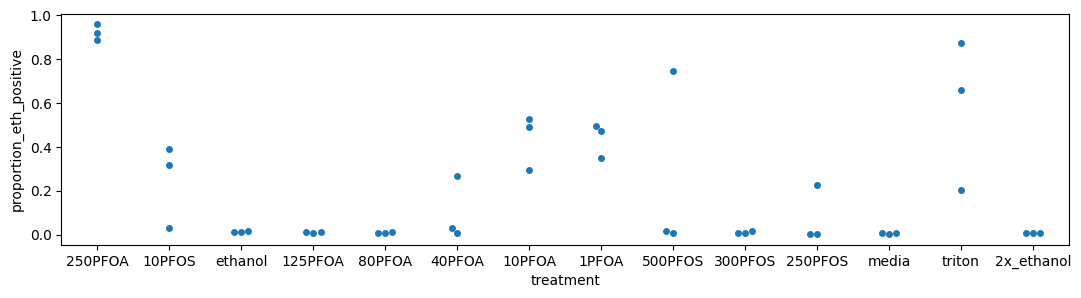

In [41]:
fig, ax = plt.subplots(figsize=(13,3))
sns.swarmplot(data = well_summary, x="treatment", y="proportion_eth_positive")